# `Rescattering2` amplitude toy in $B^+\to K^+K^+K^-$

This notebook visualizes the `Rescattering2` implementation from `DalitzPlotFitter` and generates a toy containing **only** that dynamics. Since there are two identical $K^+$, the amplitude is coherently symmetrized:

$$A_{\rm tot}(s_{13},s_{23}) = A(\sqrt{s_{13}}) + A(\sqrt{s_{23}}).$$

The toy is obtained from a phase-space pool weighted by

$$w = w_{\rm PS}\,|A_{\rm tot}|^2.$$

`Rescattering2` is an S-wave and, in the current implementation, is defined up to $m(KK)=2.0$ GeV.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    PhaseSpaceMC,
    Rescattering2,
    ResonanceContext,
    enable_x64,
    plot_dalitz,
    weighted_resample,
)

enable_x64()

SEED = 260904
N_POOL = 300_000
N_TOY = 50_000


## Amplitude definition


In [2]:
# Masses in GeV
M_B = 5.27934
M_K = 0.493677

rescattering = Rescattering2()

# Rescattering2 only explicitly uses the context spin in __call__,
# but we keep a physical ResonanceContext for B -> (K K) K.
context = ResonanceContext(
    parent_mass=M_B,
    daughter_masses=(M_K, M_K),
    bachelor_mass=M_K,
    spin=0,
    pole_mass=1.5,
    pole_width=0.0,
)

print(f"threshold KK = {rescattering.threshold_mass:.6f} GeV")
print(f"transition   = {rescattering.transition_mass:.3f} GeV")
print(f"upper edge   = {rescattering.maximum_mass:.3f} GeV")


threshold KK = 0.987354 GeV
transition   = 1.470 GeV
upper edge   = 2.000 GeV


## Modulus, phase, and intensity of `Rescattering2`


In [ ]:
m = jnp.linspace(rescattering.threshold_mass, 2.10, 1600)
a = rescattering(m, context)

m_np = np.asarray(m)
a_np = np.asarray(a)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].plot(m_np, np.abs(a_np))
axes[0].axvline(rescattering.transition_mass, ls="--", alpha=0.7)
axes[0].axvline(rescattering.maximum_mass, ls=":", alpha=0.7)
axes[0].set_ylabel(r"$|A(m_{KK})|$")

phase = np.unwrap(np.angle(a_np))
valid = np.abs(a_np) > 0
axes[1].plot(m_np[valid], np.degrees(phase[valid]))
axes[1].axvline(rescattering.transition_mass, ls="--", alpha=0.7)
axes[1].axvline(rescattering.maximum_mass, ls=":", alpha=0.7)
axes[1].set_ylabel(r"phase [deg]")

axes[2].plot(m_np, np.abs(a_np) ** 2)
axes[2].axvline(rescattering.transition_mass, ls="--", alpha=0.7)
axes[2].axvline(rescattering.maximum_mass, ls=":", alpha=0.7)
axes[2].set_xlabel(r"$m(K^+K^-)$ [GeV]")
axes[2].set_ylabel(r"$|A|^2$")

fig.suptitle("Rescattering2")
fig.tight_layout()
plt.show()


## Diagnosing `Rescattering2` oscillations

Before generating the toy, we compare two versions of the same parameterization, both using the physics implemented by the package (Chebyshev coefficients in degrees converted to radians once, the `1/(1+m^2/Lambda^2)` suppression, and `g_00(m)=0` below the $K\bar K$ threshold):

1. **Literal Laura++ anchor**: reproduces the `1.47**2` anchor used for `C0`/`F0` in the original C++ `initialise()`, which is dimensionally inconsistent and makes the amplitude discontinuous at 1.47 GeV;
2. **Package implementation**: uses the transition mass itself, `1.47`, as the anchor, which is both dimensionally consistent and continuous at 1.47 GeV.

The first version is built locally only for diagnostics. The second is the current `Rescattering2` class from the package.


In [ ]:
def chebyshev_series(x, coefficients):
    x = jnp.asarray(x)
    coeffs = tuple(coefficients)
    result = jnp.asarray(coeffs[0]) * jnp.ones_like(x)
    if len(coeffs) == 1:
        return result
    t_nm2 = jnp.ones_like(x)
    t_nm1 = x
    result = result + jnp.asarray(coeffs[1]) * t_nm1
    for coefficient in coeffs[2:]:
        t_n = 2.0 * x * t_nm1 - t_nm2
        result = result + jnp.asarray(coefficient) * t_n
        t_nm2, t_nm1 = t_nm1, t_n
    return result

def rescattering_amplitude(mass, *, anchor_squared):
    """Reproduce Rescattering2.__call__, but let the C0/F0 anchor mass be
    controlled explicitly. ``anchor_squared=True`` reproduces the literal
    Laura++ C++ construction (phi00/g00 evaluated at 1.47**2 instead of
    1.47); ``anchor_squared=False`` matches the package's corrected,
    continuous construction. Both branches otherwise follow the package's
    resAmp physics: degrees-to-radians conversion applied once, the KKbar
    threshold cut, and the 1/(1+m^2/Lambda^2) suppression.
    """
    m = jnp.asarray(mass)
    t = rescattering.transition_mass
    mmax = rescattering.maximum_mass
    anchor = t * t if anchor_squared else t

    low_phase_coeffs = rescattering._low_phase_coefficients()
    low_mag_coeffs = rescattering._low_magnitude_coefficients()

    x_low = rescattering._scaled_mass(m, rescattering.threshold_mass, t)
    low_phase = chebyshev_series(x_low, low_phase_coeffs)
    low_mag = chebyshev_series(x_low, low_mag_coeffs)

    x_anchor = rescattering._scaled_mass(anchor, rescattering.threshold_mass, t)
    phase_anchor = chebyshev_series(x_anchor, low_phase_coeffs)
    mag_anchor = chebyshev_series(x_anchor, low_mag_coeffs)

    c0 = (phase_anchor + rescattering.C1 - rescattering.C2 + rescattering.C3
          - rescattering.C4 + rescattering.C5)
    f0 = (mag_anchor + rescattering.F1 - rescattering.F2 + rescattering.F3
          - rescattering.F4)

    high_phase_coeffs = (c0, rescattering.C1, rescattering.C2, rescattering.C3,
                          rescattering.C4, rescattering.C5)
    high_mag_coeffs = (f0, rescattering.F1, rescattering.F2,
                        rescattering.F3, rescattering.F4)

    x_high = rescattering._scaled_mass(m, t, mmax)
    high_phase = chebyshev_series(x_high, high_phase_coeffs)
    high_mag = chebyshev_series(x_high, high_mag_coeffs)

    phase_deg = jnp.where(m <= t, low_phase, high_phase)
    magnitude = jnp.where(m <= t, low_mag, high_mag)
    magnitude = jnp.where(m < rescattering.threshold_mass, 0.0, magnitude)
    suppression = 1.0 / (1.0 + (m / rescattering.lambda_scale) ** 2)
    value = magnitude * suppression * jnp.exp(1j * jnp.deg2rad(phase_deg))

    inside = m < mmax
    return jnp.where(inside, value, 0.0j), c0, f0

m_diag = jnp.linspace(2 * M_K, 2.10, 5000)
a_literal, c0_literal, f0_literal = rescattering_amplitude(m_diag, anchor_squared=True)
a_package = rescattering(m_diag, context)
_, c0_package, f0_package = rescattering_amplitude(m_diag, anchor_squared=False)

print(f'C0 literal (1.47**2 anchor) = {float(c0_literal):.9f}')
print(f'C0 package (1.47 anchor)    = {float(c0_package):.9f}')
print(f'F0 literal (1.47**2 anchor) = {float(f0_literal):.9f}')
print(f'F0 package (1.47 anchor)    = {float(f0_package):.9f}')


In [ ]:
m_diag_np = np.asarray(m_diag)
variants = {
    'Laura++ literal (1.47² anchor)': np.asarray(a_literal),
    'package (1.47 anchor)': np.asarray(a_package),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

for label, amp in variants.items():
    axes[0,0].plot(m_diag_np, np.abs(amp), label=label)
    axes[0,1].plot(m_diag_np, np.real(amp), label=label)
    axes[1,0].plot(m_diag_np, np.imag(amp), label=label)

    valid = np.abs(amp) > 1e-14
    phase = np.full_like(m_diag_np, np.nan, dtype=float)
    if np.any(valid):
        phase[valid] = np.unwrap(np.angle(amp[valid]))
    axes[1,1].plot(m_diag_np, phase, label=label)

for ax in axes.flat:
    ax.axvline(rescattering.threshold_mass, ls=':', alpha=0.6)
    ax.axvline(rescattering.transition_mass, ls='--', alpha=0.6)
    ax.axvline(rescattering.maximum_mass, ls=':', alpha=0.6)
    ax.grid(alpha=0.2)

axes[0,0].set_ylabel(r'$|A|$')
axes[0,1].set_ylabel(r'$\Re A$')
axes[1,0].set_ylabel(r'$\Im A$')
axes[1,1].set_ylabel('unwrapped phase [rad]')
axes[1,0].set_xlabel(r'$m$ [GeV]')
axes[1,1].set_xlabel(r'$m$ [GeV]')
axes[0,0].legend()
fig.suptitle('Rescattering2: literal Laura++ anchor vs package anchor')
fig.tight_layout()
plt.show()


### Zoom on the region-II anchor discontinuity

Both variants are exactly zero below the $K\bar K$ threshold and coincide in region I, since only the `C0`/`F0` anchor mass used for region II differs between them. The zoom below isolates region II, `1.47–2.00 GeV`, where the literal `1.47**2` anchor produces a visible jump at the 1.47 GeV boundary that the package's `1.47` anchor does not.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for label, amp in variants.items():
    axes[0].plot(m_diag_np, np.abs(amp), label=label)
    axes[1].plot(m_diag_np, np.abs(amp), label=label)

axes[0].set_xlim(2 * M_K, 1.05)
axes[1].set_xlim(1.43, 2.02)
axes[0].axvline(rescattering.threshold_mass, ls=':', alpha=0.6)
axes[1].axvline(rescattering.transition_mass, ls='--', alpha=0.6)
axes[1].axvline(rescattering.maximum_mass, ls=':', alpha=0.6)
axes[0].set_title('Below / around KK threshold')
axes[1].set_title('Region II: 1.47–2.00 GeV')
for ax in axes:
    ax.set_xlabel(r'$m$ [GeV]')
    ax.set_ylabel(r'$|A|$')
    ax.grid(alpha=0.2)
axes[0].legend()
fig.tight_layout()
plt.show()


## Phase-space pool generation

We use the ordering $(p_1,p_2,p_3)=(K^+,K^+,K^-)$. So the two relevant masses are $m_{13}=m(K^+_1K^-)$ and $m_{23}=m(K^+_2K^-)$.

In [7]:
ps_generator = PhaseSpaceMC(M_B, (M_K, M_K, M_K))
pool = ps_generator.generate(N_POOL, seed=SEED)

m13 = jnp.sqrt(pool.s13)
m23 = jnp.sqrt(pool.s23)

a13 = rescattering(m13, context)
a23 = rescattering(m23, context)

# Bose symmetrization for the two identical K+.
a_total = a13 + a23
intensity = jnp.abs(a_total) ** 2
target_weights = pool.weights * intensity

print(f"pool size       = {pool.size:,}")
print(f"max |A_tot|^2   = {float(jnp.max(intensity)):.6g}")
print(f"mean |A_tot|^2  = {float(jnp.mean(intensity)):.6g}")
print(f"nonzero fraction= {float(jnp.mean(intensity > 0)):.4f}")


pool size       = 300,000
max |A_tot|^2   = 0.354195
mean |A_tot|^2  = 0.00667635
nonzero fraction= 0.4700


## Dalitz ponderado antes do unweighting


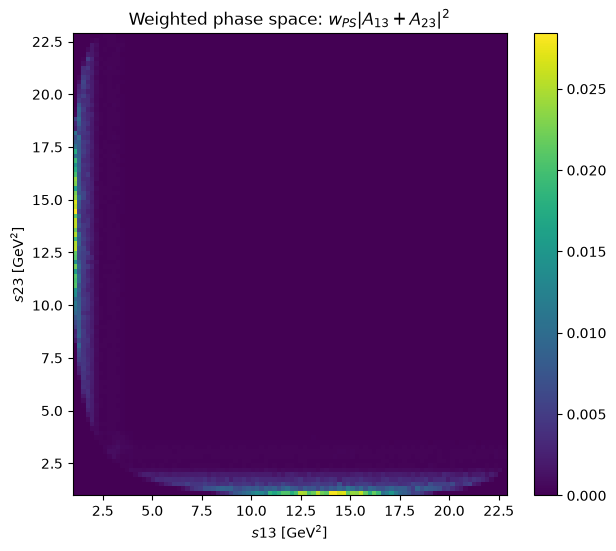

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_dalitz(
    pool,
    x="s13",
    y="s23",
    weights=np.asarray(target_weights),
    bins=100,
    ax=ax,
    title=r"Weighted phase space: $w_{PS}|A_{13}+A_{23}|^2$",
)
plt.show()


## Unweighted toy


In [9]:
toy = weighted_resample(
    jax.random.key(SEED + 1),
    pool,
    target_weights,
    N_TOY,
    replace=True,
)

print(f"toy size = {toy.size:,}")


toy size = 50,000


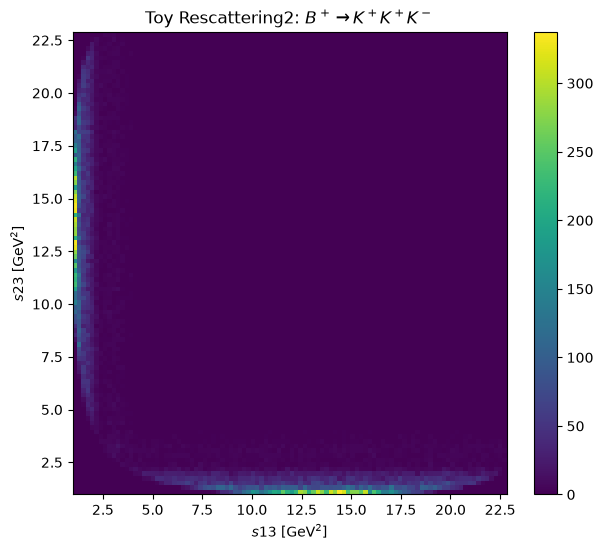

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_dalitz(
    toy,
    x="s13",
    y="s23",
    bins=100,
    ax=ax,
    title=r"Toy Rescattering2: $B^+\to K^+K^+K^-$",
)
plt.show()


## Projections onto $m(K^+K^-)$


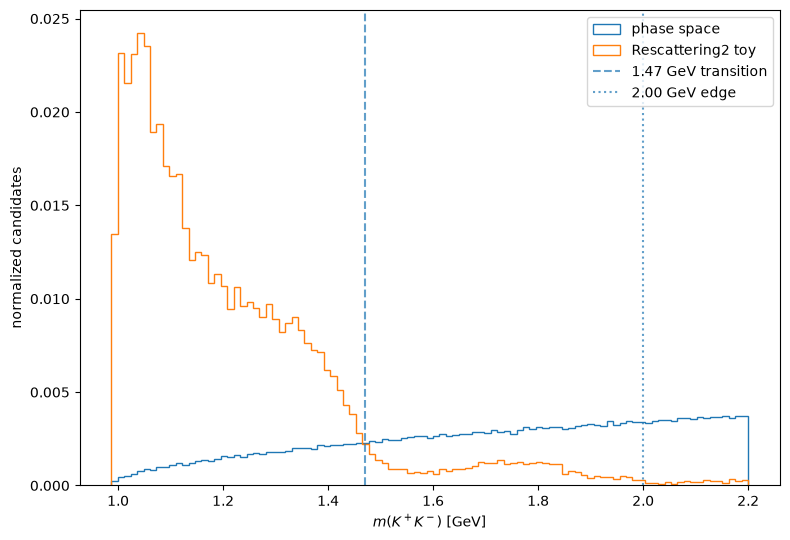

In [11]:
toy_m13 = np.sqrt(np.asarray(toy.s13))
toy_m23 = np.sqrt(np.asarray(toy.s23))
toy_mkk = np.concatenate([toy_m13, toy_m23])

ps_mkk = np.concatenate([
    np.sqrt(np.asarray(pool.s13)),
    np.sqrt(np.asarray(pool.s23)),
])
ps_w = np.concatenate([
    np.asarray(pool.weights),
    np.asarray(pool.weights),
])

bins = np.linspace(2 * M_K, 2.20, 100)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.hist(ps_mkk, bins=bins, weights=ps_w / np.sum(ps_w), histtype="step", label="phase space")
ax.hist(toy_mkk, bins=bins, weights=np.ones_like(toy_mkk) / toy_mkk.size, histtype="step", label="Rescattering2 toy")
ax.axvline(rescattering.transition_mass, ls="--", alpha=0.7, label="1.47 GeV transition")
ax.axvline(rescattering.maximum_mass, ls=":", alpha=0.7, label="2.00 GeV edge")
ax.set_xlabel(r"$m(K^+K^-)$ [GeV]")
ax.set_ylabel("normalized candidates")
ax.legend()
fig.tight_layout()
plt.show()


## Low-mass range

Zoom on the region where the parameterization is active, useful for directly comparing the amplitude structure with the toy projection.

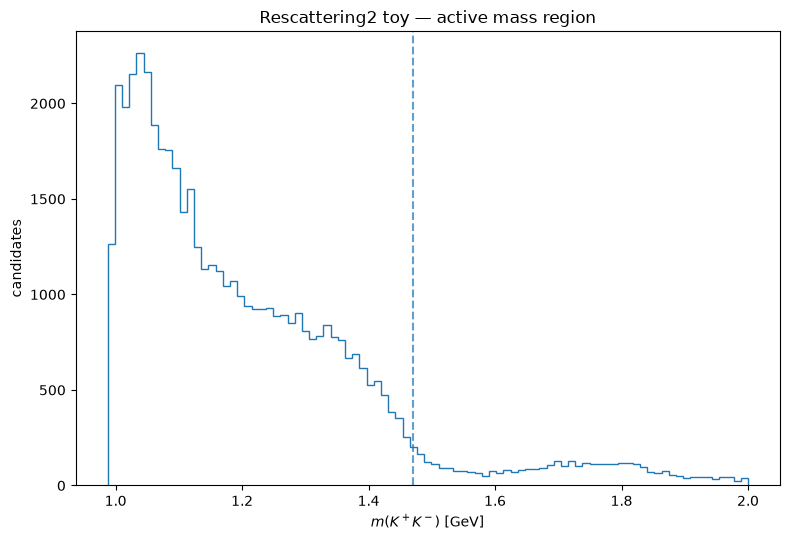

In [12]:
bins_zoom = np.linspace(2 * M_K, rescattering.maximum_mass, 90)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.hist(toy_mkk, bins=bins_zoom, histtype="step")
ax.axvline(rescattering.transition_mass, ls="--", alpha=0.7)
ax.set_xlabel(r"$m(K^+K^-)$ [GeV]")
ax.set_ylabel("candidates")
ax.set_title("Rescattering2 toy — active mass region")
fig.tight_layout()
plt.show()


### Remark

This notebook isolates `Rescattering2`; it therefore does not include other resonances, efficiency, background, or the charm veto. This makes it useful as a sanity test of the lineshape and its symmetrization before inserting it into a full model.